## Lab 4: Generating CDFs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Question 1

##### Part 1

In [2]:
K = 3
grid = np.arange(1, K + 1) / K
grid

array([0.33333333, 0.66666667, 1.        ])

##### Part 2

In [3]:
rng = np.random.default_rng(seed=100)
draw = rng.choice(grid)
draw

np.float64(1.0)

##### Part 3

<Axes: ylabel='Proportion'>

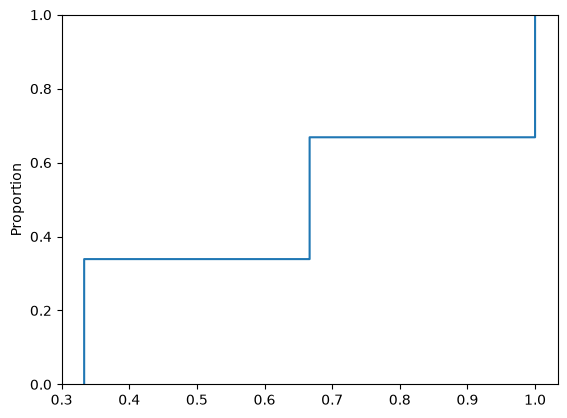

In [4]:
n = 5_000
draws = rng.choice(grid, size=n)
sns.ecdfplot(draws)

##### Part 4

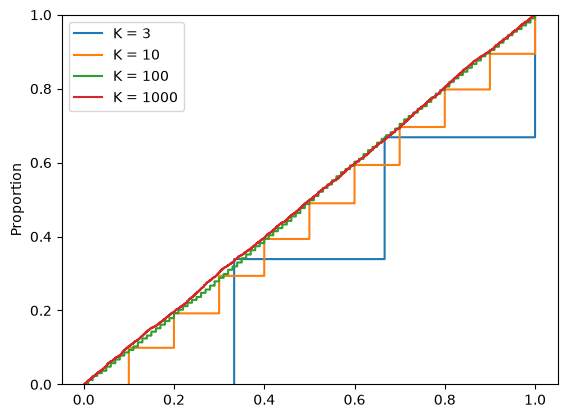

In [5]:
rng = np.random.default_rng(seed=100)

n = 5_000
for K in [3, 10, 100, 1_000]:
    grid = np.arange(1, K + 1) / K
    draws = rng.choice(grid, size=n)
    sns.ecdfplot(draws, label=f"K = {K}")
plt.legend()

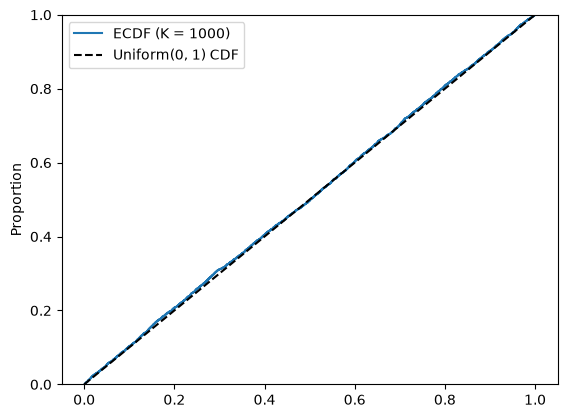

In [6]:
rng = np.random.default_rng(seed=100)

K = 1_000
n = 5_000
grid = np.arange(1, K + 1) / K
draws = rng.choice(grid, size=n)

x = np.linspace(0, 1, 500)
sns.ecdfplot(draws, label="ECDF (K = 1000)")
plt.plot(x, stats.uniform.cdf(x, loc=0, scale=1), color="black", linestyle="--", label="Uniform(0, 1) CDF")
plt.legend()

As K increases, the draws approach the uniform distribution between 0 and 1.

### Question 2

##### Part 1

In [7]:
rng = np.random.default_rng(seed=100)
n = 32
data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=n)
data

array([ 1.16041041,  0.33447296, -0.73139919, -1.5832622 ,  1.64078696,
        0.33418779,  1.0055011 ,  1.42145731,  0.65178613, -1.07390104,
        1.66789211, -0.74568234,  0.4478154 ,  0.2807186 ,  0.34610627,
        0.12210302,  1.71742227,  0.00674144,  0.93884974, -0.02022419,
        1.72399502,  1.65799497, -0.36869111, -0.61686898,  1.25463058,
        1.03689185,  0.66313516, -0.31690346, -0.38186478, -1.27600739,
        0.43473605, -1.44660409])

##### Part 2

In [8]:
np.sqrt(n) * data.mean()

np.float64(1.818365101776832)

##### Part 3

<Axes: ylabel='Proportion'>

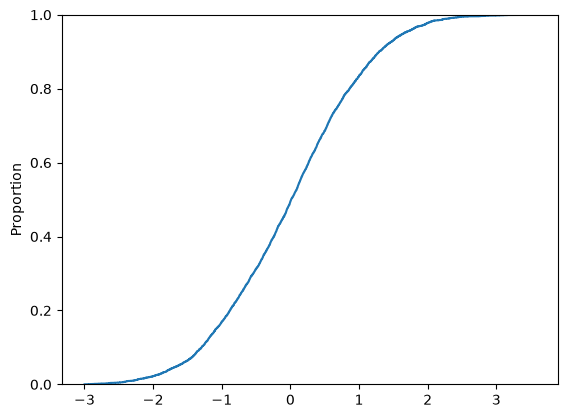

In [9]:
rng = np.random.default_rng(seed=100)

b = 5_000
data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
z = np.sqrt(n) * data.mean(axis=1)
sns.ecdfplot(z)

##### Part 4

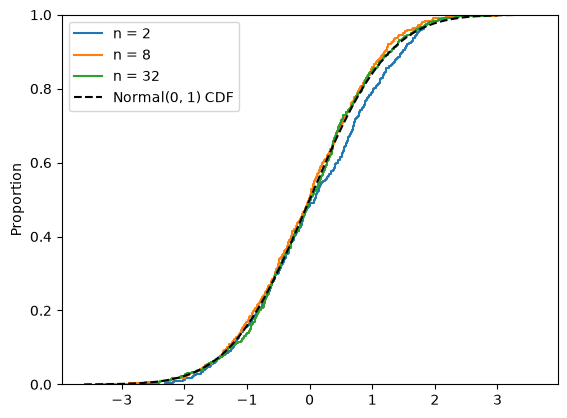

In [10]:
rng = np.random.default_rng(seed=100)

b = 500 # lowered b to make the differences easier to see
x = np.linspace(-3.6, 3.6, 500)
for n in [2, 8, 32]:
    data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
    z = np.sqrt(n) * data.mean(axis=1)
    sns.ecdfplot(z, label=f"n = {n}")
plt.plot(x, stats.norm.cdf(x, loc=0, scale=1), color="black", linestyle="--", label="Normal(0, 1) CDF")
plt.legend()

As n increases, the sample mean approaches the normal distribution with mean 0 and variance 1.

### Question 3

##### Part 1

In [11]:
rng = np.random.default_rng(seed=100)
n = 40
p = 1 / 2
flips = rng.choice([0, 1], size=n, p=[1 - p, p])
flips

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0])

##### Part 2

In [12]:
heads = flips.sum()
heads - n * p

np.float64(5.0)

##### Part 3

In [13]:
(heads - n * p) / np.sqrt(n * p * (1 - p))

np.float64(1.5811388300841895)

##### Part 4

<Axes: ylabel='Proportion'>

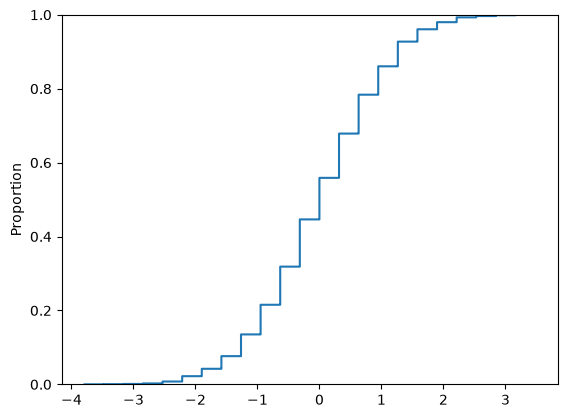

In [14]:
rng = np.random.default_rng(seed=100)

b = 5_000
flips = rng.choice([0, 1], size=(b, n), p=[1 - p, p])
heads = flips.sum(axis=1)
z = (heads - n * p) / np.sqrt(n * p * (1 - p))
sns.ecdfplot(z)

##### Part 5

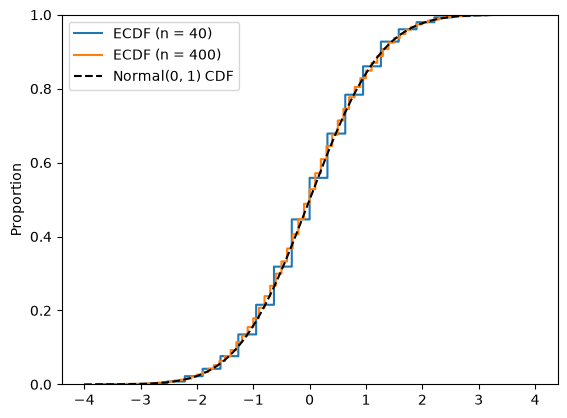

In [15]:
rng = np.random.default_rng(seed=100)

p = 1 / 2
b = 5_000
x = np.linspace(-4, 4, 500)
for n in [40, 400]:
    flips = rng.choice([0, 1], size=(b, n), p=[1 - p, p])
    heads = flips.sum(axis=1)
    z = (heads - n * p) / np.sqrt(n * p * (1 - p))
    sns.ecdfplot(z, label=f"ECDF (n = {n})")
plt.plot(x, stats.norm.cdf(x, loc=0, scale=1), color="black", linestyle="--", label="Normal(0, 1) CDF")
plt.legend()

As n increases, the standardized count of heads approaches the normal distribution with mean 0 and variance 1.

##### Part 6

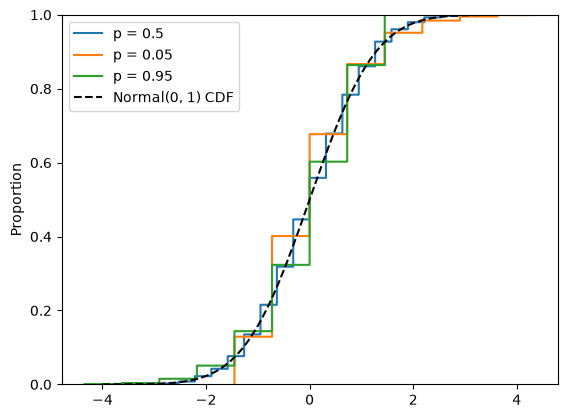

In [16]:
rng = np.random.default_rng(seed=100)

n = 40
b = 5_000
x = np.linspace(-4, 4, 500)
for p in [0.5, 0.05, 0.95]:
    flips = rng.choice([0, 1], size=(b, n), p=[1 - p, p])
    heads = flips.sum(axis=1)
    z = (heads - n * p) / np.sqrt(n * p * (1 - p))
    sns.ecdfplot(z, label=f"p = {p}")
plt.plot(x, stats.norm.cdf(x, loc=0, scale=1), color="black", linestyle="--", label="Normal(0, 1) CDF")
plt.legend()

Moving p away from 1/2 makes the standardized count skewed when n = 40, with the long tail on the high side for small p and on the low side for large p. It still approaches the normal as n increases, but the closer p is to 0 or 1, the more flips you need for it to look normal.

### Question 4

##### Part 1

In [17]:
rng = np.random.default_rng(seed=100)

r = 1
dt = 1e-3
period = 0
while True:
    period += 1
    if rng.random() < r * dt:
        break
period


104

##### Part 2

In [18]:
period * dt

0.10400000000000001

##### Part 3

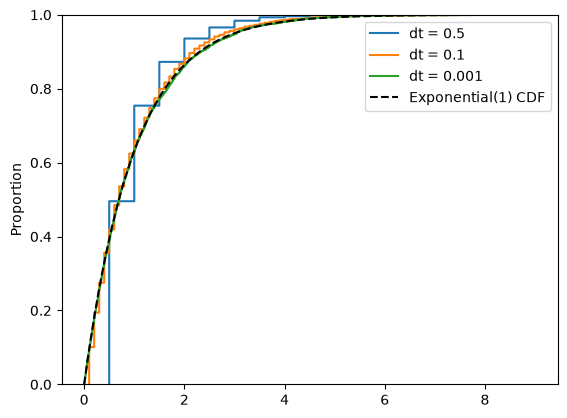

In [19]:
rng = np.random.default_rng(seed=100)

n = 5_000
x = np.linspace(0, 9, 500)
for dt in [0.5, 0.1, 0.001]:
    periods = []
    for i in range(n):
        period = 0
        while True:
            period += 1
            if rng.random() < r * dt:
                break
        periods.append(period)
    times = np.array(periods) * dt
    sns.ecdfplot(times, label=f"dt = {dt}")
plt.plot(x, stats.expon.cdf(x, scale=1 / r), color="black", linestyle="--", label="Exponential(1) CDF")
plt.legend()

##### Part 4

As dt goes to zero, the time to termination approaches the exponential distribution, with a mean of 1/r.

##### Part 5

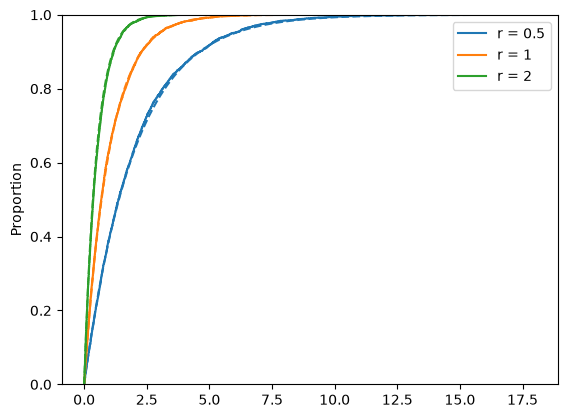

In [20]:
rng = np.random.default_rng(seed=100)

n = 5_000
rs = [0.5, 1, 2]
x = np.linspace(0, 18, 500)
for j in range(len(rs)):
    r = rs[j]
    periods = []
    for i in range(n):
        period = 0
        while True:
            period += 1
            if rng.random() < r * dt:
                break
        periods.append(period)
    times = np.array(periods) * dt
    sns.ecdfplot(times, label=f"r = {r}")
    plt.plot(x, stats.expon.cdf(x, scale=1 / r), color=sns.color_palette()[j], linestyle="--")
plt.legend()

Changing r only rescales time. The mean time is 1/r, so higher r terminates faster and lower r is slower, while the shape stays exponential.

### Question 7
Did this one extra since I had some free time and it looked interesting. Feel free to drop it or keep it for grading

##### Part 1

In [21]:
K = 100_000
ranks = np.arange(1, K + 1)
ranks

array([     1,      2,      3, ...,  99998,  99999, 100000],
      shape=(100000,))

##### Part 2

In [22]:
s = 1
sizes = (K / ranks) ** s
sizes

array([1.00000000e+05, 5.00000000e+04, 3.33333333e+04, ...,
       1.00002000e+00, 1.00001000e+00, 1.00000000e+00], shape=(100000,))

##### Part 3

In [23]:
rng = np.random.default_rng(seed=100)

n = 5_000
r = rng.integers(1, K + 1, size=n)
sizes_sample = (K / r) ** s
sizes_sample

array([1.30396797, 1.19761913, 8.05282654, ..., 2.28336568, 5.33504055,
       1.08966885], shape=(5000,))

##### Part 4

<Axes: ylabel='Proportion'>

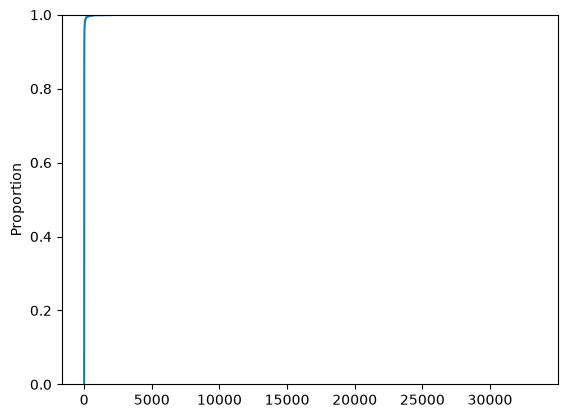

In [24]:
sns.ecdfplot(sizes_sample)

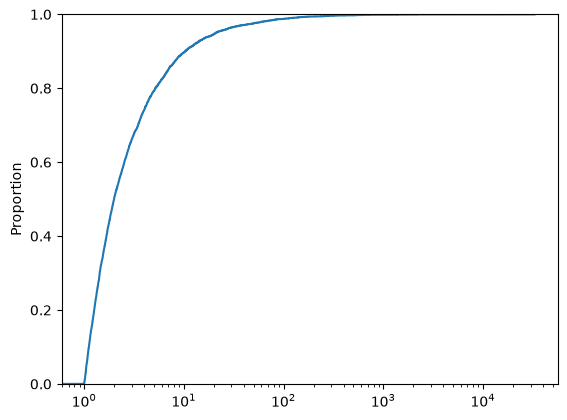

In [25]:
sns.ecdfplot(sizes_sample)
plt.xscale("log")

##### Part 5

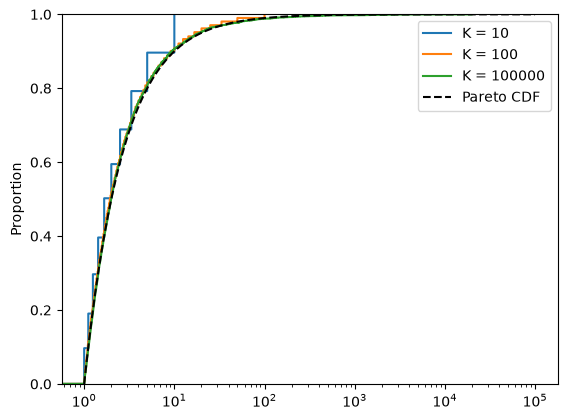

In [26]:
rng = np.random.default_rng(seed=100)

n = 5_000
x = np.logspace(0, 5, 500)
for K in [10, 100, 100_000]:
    r = rng.integers(1, K + 1, size=n)
    sizes_k = (K / r) ** s
    sns.ecdfplot(sizes_k, label=f"K = {K}")
plt.plot(x, stats.pareto.cdf(x, b=1, scale=1), color="black", linestyle="--", label="Pareto CDF")
plt.xscale("log")
plt.legend()

As K becomes large, the simulated sizes approach the Pareto distribution, with minimum value 1 and shape parameter 1.

##### Part 6

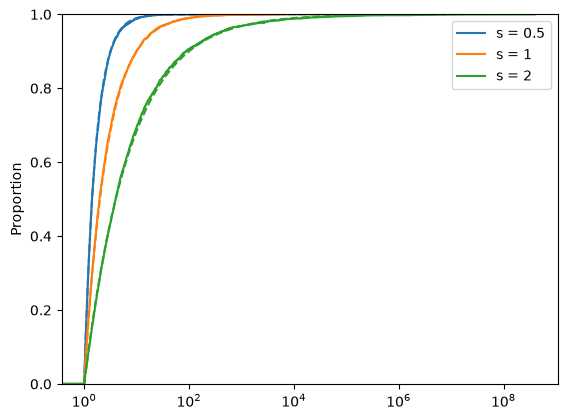

In [27]:
rng = np.random.default_rng(seed=100)

n = 5_000
x = np.logspace(0, 5, 500)
ss = [0.5, 1, 2]
for j in range(len(ss)):
    s = ss[j]
    r = rng.integers(1, K + 1, size=n)
    sizes_s = (K / r) ** s
    sns.ecdfplot(sizes_s, label=f"s = {s}")
    plt.plot(x, stats.pareto.cdf(x, b=1 / s, scale=1), color=sns.color_palette()[j], linestyle="--")
plt.xscale("log")
plt.legend()

Larger s makes the tail heavier and smaller s makes it lighter. The distribution stays Pareto, with shape parameter 1/s.

### AI Acknowledgment
This work is my own; AI assistance was used for spelling, grammar, and drafting parts of the code.